TinyTimeMixers (TTMs) are compact pre-trained models for Multivariate Time-Series Forecasting, open-sourced by IBM Research. With less than 1 Million parameters, TTM outperforms several popular benchmarks in zero-shot and few-shot forecasting. In this recipe, we demonstrate few-shot fine-tuning on a real-world energy demand dataset from Spain.

In [1]:
!pip install "granite_tsfm[notebooks]==0.2.23"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 141.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.2 MB/s eta 0:00:00


In [2]:
import math
import os
import numpy as np
import pandas as pd
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
from tsfm_public import (
    TimeSeriesForecastingPipeline,
    TimeSeriesPreprocessor,
    TinyTimeMixerForPrediction,
    TrackingCallback,
    count_parameters,
    get_datasets,
)
from tsfm_public.toolkit.time_series_preprocessor import prepare_data_splits
from tsfm_public.toolkit.visualization import plot_predictions

Configuration Variables

In [3]:
timestamp_column = "time"
target_columns = ["total load actual", "generation solar"]
TTM_MODEL_REVISION = "512-96-ft-r2.1"
context_length = 512
prediction_length = 96
fewshot_fraction = 0.05
OUT_DIR = "/tmp/ttm_results"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
DATA_FILE_PATH = "hf://datasets/vitaliy-sharandin/energy-consumption-hourly-spain/energy_dataset.csv"
DATA_FILE_EXOG_PATH = "hf://datasets/vitaliy-sharandin/energy-consumption-weather-hourly-spain/weather_features.csv"

Filling missing values


In [5]:
input_df = pd.read_csv(DATA_FILE_PATH, parse_dates=[timestamp_column])
input_df = input_df.ffill()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


We also process and include exogenous weather data. We calculate a daily rolling average and then take the median across all cities to get a country-level forecast.

In [6]:
exog_timestamp_column = "dt_iso"
exog_data = pd.read_csv(
    DATA_FILE_EXOG_PATH,
    parse_dates=[exog_timestamp_column],
)
keep_cols = [
    c for c in exog_data.columns if c not in ["weather_id", "weather_main", "weather_description", "weather_icon"]
]
exog_data = exog_data[keep_cols]
value_cols = [c for c in keep_cols if c not in ["dt_iso", "city_name"]]
city_data = []
for city in exog_data.city_name.unique():
    df = (
        exog_data[exog_data.city_name == city].set_index("dt_iso")[value_cols].rolling(window=24, min_periods=1).mean()
    )
    df["city_name"] = city
    df = df.reset_index()
    city_data.append(df)
exog_df = pd.concat(city_data, axis=0).sort_values(by="dt_iso")
exog_df = exog_df.groupby("dt_iso")[value_cols].median()

Now we join the target data with the exogenous data.

In [7]:
input_df = input_df.merge(exog_df, left_on=timestamp_column, right_on=exog_timestamp_column)

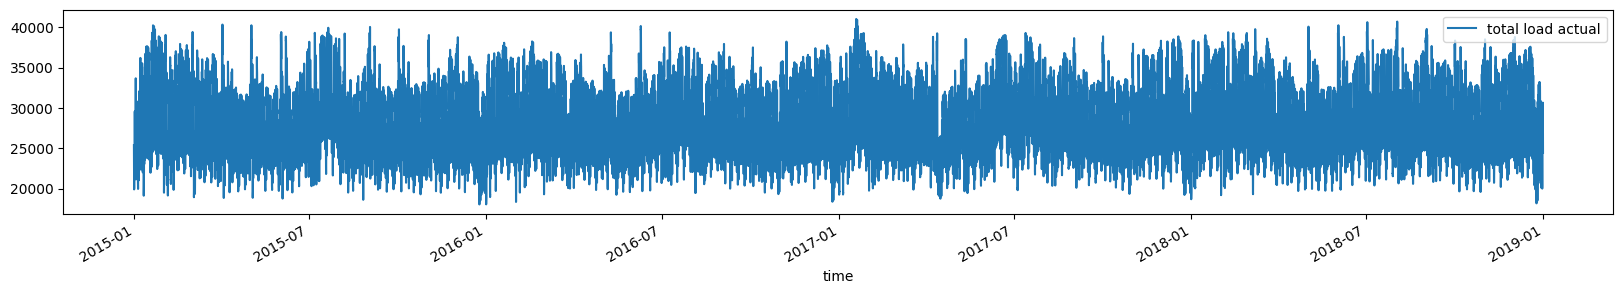

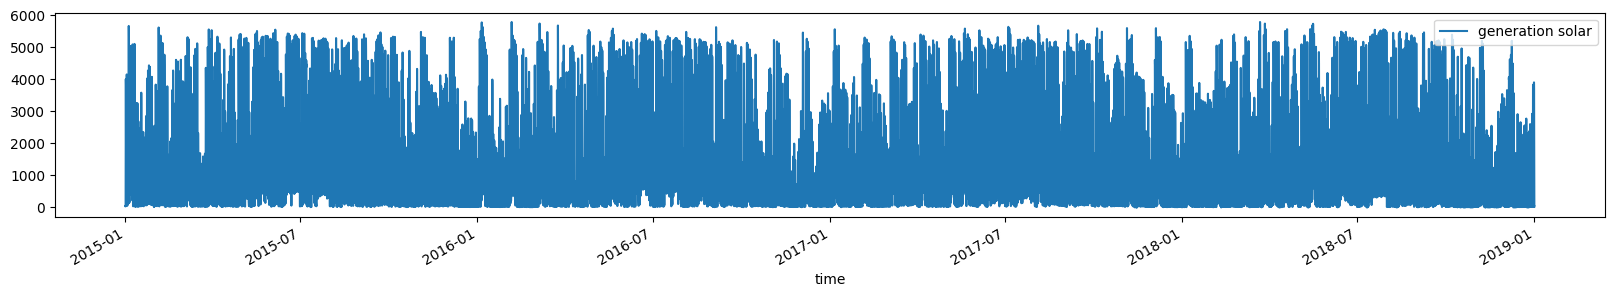

In [8]:
for target_column in target_columns:
    input_df.plot(x=timestamp_column, y=target_column, figsize=(20, 3))

We define the control columns (features known in the future) and set up the time series preprocessor to split our data.

In [9]:
split_config = {"train": 0.6, "test": 0.2}
column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": [],
    "target_columns": target_columns,
    "control_columns": [
        "temp",
        "temp_min",
        "temp_max",
        "pressure",
        "wind_speed",
        "wind_deg",
        "humidity",
        "rain_1h",
        "rain_3h",
        "clouds_all",
    ],
}
tsp = TimeSeriesPreprocessor(
    **column_specifiers,
    context_length=context_length,
    prediction_length=prediction_length,
    scaling=True,
    encode_categorical=False,
    scaler_type="standard",
)
train_df, valid_df, test_df = prepare_data_splits(input_df, context_length=context_length, split_config=split_config)

Fine-tuning the Model

In [10]:
set_seed(42)
finetune_forecast_model = TinyTimeMixerForPrediction.from_pretrained(
    "ibm-granite/granite-timeseries-ttm-r2",
    num_input_channels=tsp.num_input_channels,
    prediction_channel_indices=tsp.prediction_channel_indices,
    exogenous_channel_indices=tsp.exogenous_channel_indices,
    fcm_use_mixer=True,
    fcm_context_length=10,
    enable_forecast_channel_mixing=True,
    decoder_mode="mix_channel",
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.24M [00:00<?, ?B/s]

Some weights of TinyTimeMixerForPrediction were not initialized from the model checkpoint at ibm-granite/granite-timeseries-ttm-r2 and are newly initialized: ['decoder.decoder_block.mixers.0.channel_feature_mixer.gating_block.attn_layer.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.gating_block.attn_layer.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc1.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc1.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc2.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc2.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.norm.norm.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.norm.norm.weight', 'decoder.decoder_block.mixers.1.channel_feature_mixer.gating_block.attn_layer.bias', 'decoder.decoder_block.mixers.1.channel_feature_mixer.gating_block.attn_layer.weight', 'decoder.decoder_block.mixers.1.channel_feature_mixer.mlp.fc1.bias', 'dec

In [11]:
for param in finetune_forecast_model.backbone.parameters():
    param.requires_grad = False
train_dataset, valid_dataset, test_dataset = get_datasets(
    tsp,
    input_df,
    split_config,
    fewshot_fraction=fewshot_fraction,
    fewshot_location="first",
    use_frequency_token=finetune_forecast_model.config.resolution_prefix_tuning,
)

Now we set up the training arguments, optimizer, and scheduler using the Hugging Face Trainer.

In [12]:
learning_rate: float = 0.0004
num_epochs: int = 200
patience: int = 10
batch_size: int = 256

finetune_forecast_args = TrainingArguments(
    output_dir=os.path.join(OUT_DIR, "output"),
    overwrite_output_dir=True,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    do_eval=True,
    eval_strategy="epoch",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    dataloader_num_workers=4,
    report_to=None,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    logging_dir=os.path.join(OUT_DIR, "logs"),
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    use_cpu=device != "cuda",
)

early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=patience,
    early_stopping_threshold=0.00001,
)
tracking_callback = TrackingCallback()

optimizer = AdamW(finetune_forecast_model.parameters(), lr=learning_rate)
scheduler = OneCycleLR(
    optimizer,
    learning_rate,
    epochs=num_epochs,
    steps_per_epoch=math.ceil(len(train_dataset) / (batch_size)),
)

finetune_forecast_trainer = Trainer(
    model=finetune_forecast_model,
    args=finetune_forecast_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    callbacks=[early_stopping_callback, tracking_callback],
    optimizers=(optimizer, scheduler),
)

start the training process on 5% of the data

In [13]:
finetune_forecast_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: basitmal36 (basitmal36-university-of-paris-saclay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.995000,0.616265
2,0.918600,0.591890
3,0.933000,0.567489
4,0.967800,0.543854
5,0.850800,0.520246
6,0.879300,0.497940
7,0.814800,0.476314
8,0.772800,0.456356
9,0.723700,0.440890
10,0.697700,0.431806


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: T

[TrackingCallback] Mean Epoch Time = 1.9700886130332946 seconds, Total Train Time = 348.03434205055237


TrainOutput(global_step=160, training_loss=0.5751202717423439, metrics={'train_runtime': 385.0245, 'train_samples_per_second': 483.606, 'train_steps_per_second': 2.078, 'total_flos': 1501247728189440.0, 'train_loss': 0.5751202717423439, 'epoch': 40.0})

Evaluate the Model

In [14]:
pipeline = TimeSeriesForecastingPipeline(
    finetune_forecast_model,
    device=device,
    feature_extractor=tsp,
    batch_size=batch_size,
)
finetune_forecast = pipeline(test_df)

Device set to use cuda


In [15]:
def custom_metric(actual, prediction, column_header="results"):
    a = np.asarray(actual.tolist())
    p = np.asarray(prediction.tolist())
    mask = ~np.any(np.isnan(a), axis=1)
    mse = np.mean(np.square(a[mask, :] - p[mask, :]))
    mae = np.mean(np.abs(a[mask, :] - p[mask, :]))
    return pd.DataFrame(
        {
            column_header: {
                "mean_squared_error": mse,
                "root_mean_squared_error": np.sqrt(mse),
                "mean_absolute_error": mae,
            }
        }
    )

custom_metric(
    finetune_forecast["total load actual"],
    finetune_forecast["total load actual_prediction"],
    "fine-tune forecast (total load)",
)

,fine-tune forecast (total load)
mean_squared_error,8.553187e+06
root_mean_squared_error,2.924583e+03
mean_absolute_error,2.256128e+03


we can plot the predictions against the actual values for some random samples from our test set.

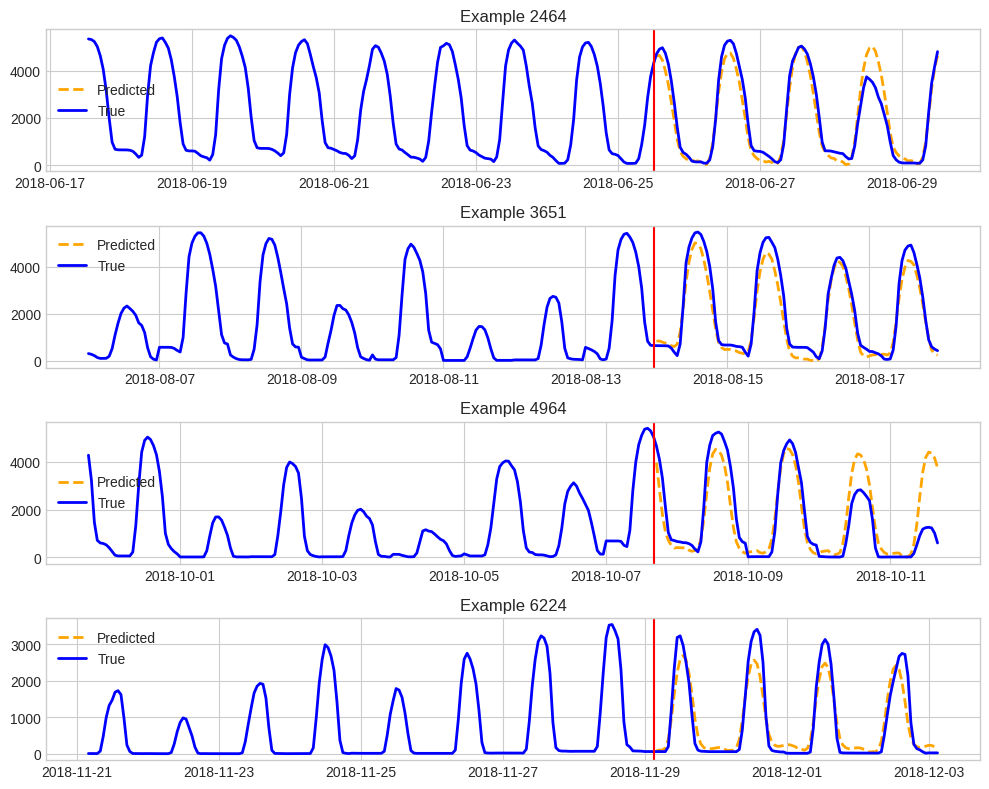

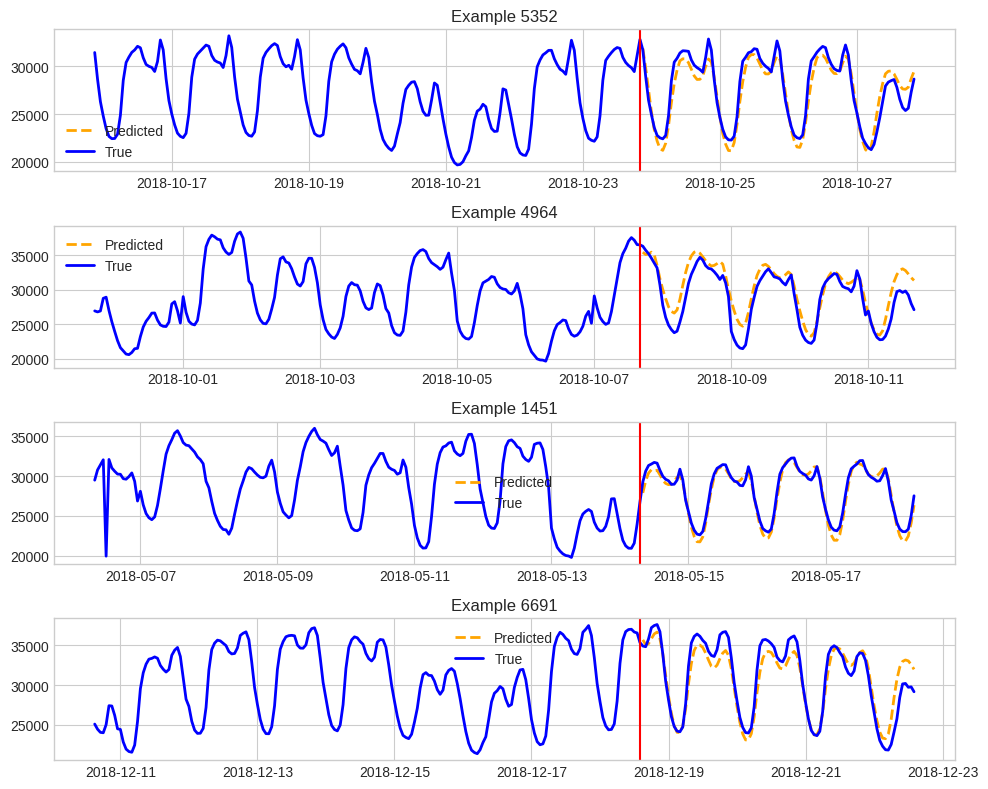

In [16]:
plot_predictions(
    input_df=test_df,
    predictions_df=finetune_forecast,
    timestamp_column=timestamp_column,
    freq=tsp.freq,
    plot_dir=None,
    plot_prefix="Test",
    channel="generation solar",
    plot_context=2 * prediction_length,
    indices=[2464, 3651, 4964, 6224],
    num_plots=4,
)

plot_predictions(
    input_df=test_df,
    predictions_df=finetune_forecast,
    timestamp_column=timestamp_column,
    freq=tsp.freq,
    plot_dir=None,
    plot_prefix="Test",
    channel="total load actual",
    plot_context=2 * prediction_length,
    indices=[5352, 4964, 1451, 6691],
    num_plots=4,
)

Making a Forecast
To simulate a real-world scenario, we use historical data and known future control variables to predict the next period

In [17]:
historical_df = input_df.iloc[-context_length - prediction_length : -prediction_length].copy()
controls_df = input_df.iloc[-prediction_length:][column_specifiers["control_columns"]].copy()

pipeline = TimeSeriesForecastingPipeline(
    finetune_forecast_trainer.model,
    feature_extractor=tsp,
    device=device,
)

future_forecast = pipeline(historical_df, future_time_series=controls_df)

Device set to use cuda


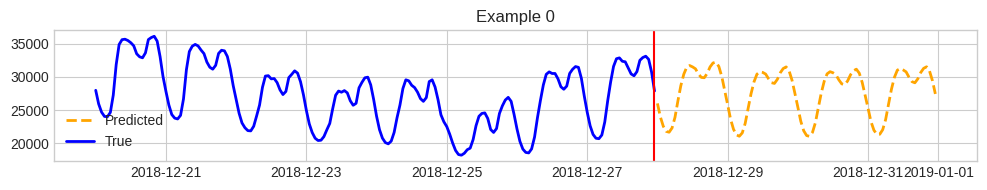

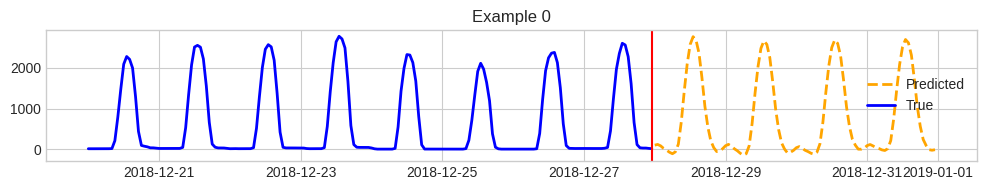

In [18]:
historical_df[timestamp_column] = pd.to_datetime(historical_df[timestamp_column])

plot_predictions(
    input_df=historical_df,
    predictions_df=future_forecast,
    freq=tsp.freq,
    timestamp_column=timestamp_column,
    channel=target_columns[0],
)
plot_predictions(
    input_df=historical_df,
    predictions_df=future_forecast,
    freq=tsp.freq,
    timestamp_column=timestamp_column,
    channel=target_columns[1],
)